Data generated:
  [small ] TSP: 5 cities | Knapsack: 5 items, capacity=24
  [medium] TSP: 25 cities | Knapsack: 25 items, capacity=127
  [large ] TSP: 50 cities | Knapsack: 50 items, capacity=248

TSP Greedy:
  [small ] cost=261.44 | time=0.0000s
  [medium] cost=531.63 | time=0.0003s
  [large ] cost=694.76 | time=0.0010s

TSP Local Search:
  [small ] cost=227.35 | time=0.0001s
  [medium] cost=415.97 | time=0.0258s
  [large ] cost=568.11 | time=0.0839s

TSP Simulated Annealing:
  [small ] cost=227.35 | time=0.0490s
  [medium] cost=415.95 | time=0.0969s
  [large ] cost=626.31 | time=0.0977s

TSP Genetic Algorithm:
  [small ] cost=227.35 | time=0.4032s
  [medium] cost=407.88 | time=1.5176s
  [large ] cost=842.77 | time=6.2388s

Knapsack Greedy:
  [small ] value=273 | items=3 | time=0.0001s
  [medium] value=1029 | items=15 | time=0.0001s
  [large ] value=2162 | items=33 | time=0.0003s

Knapsack Local Search:
  [small ] value=273 | items=3 | time=0.0058s
  [medium] value=1029 | items=15 | t

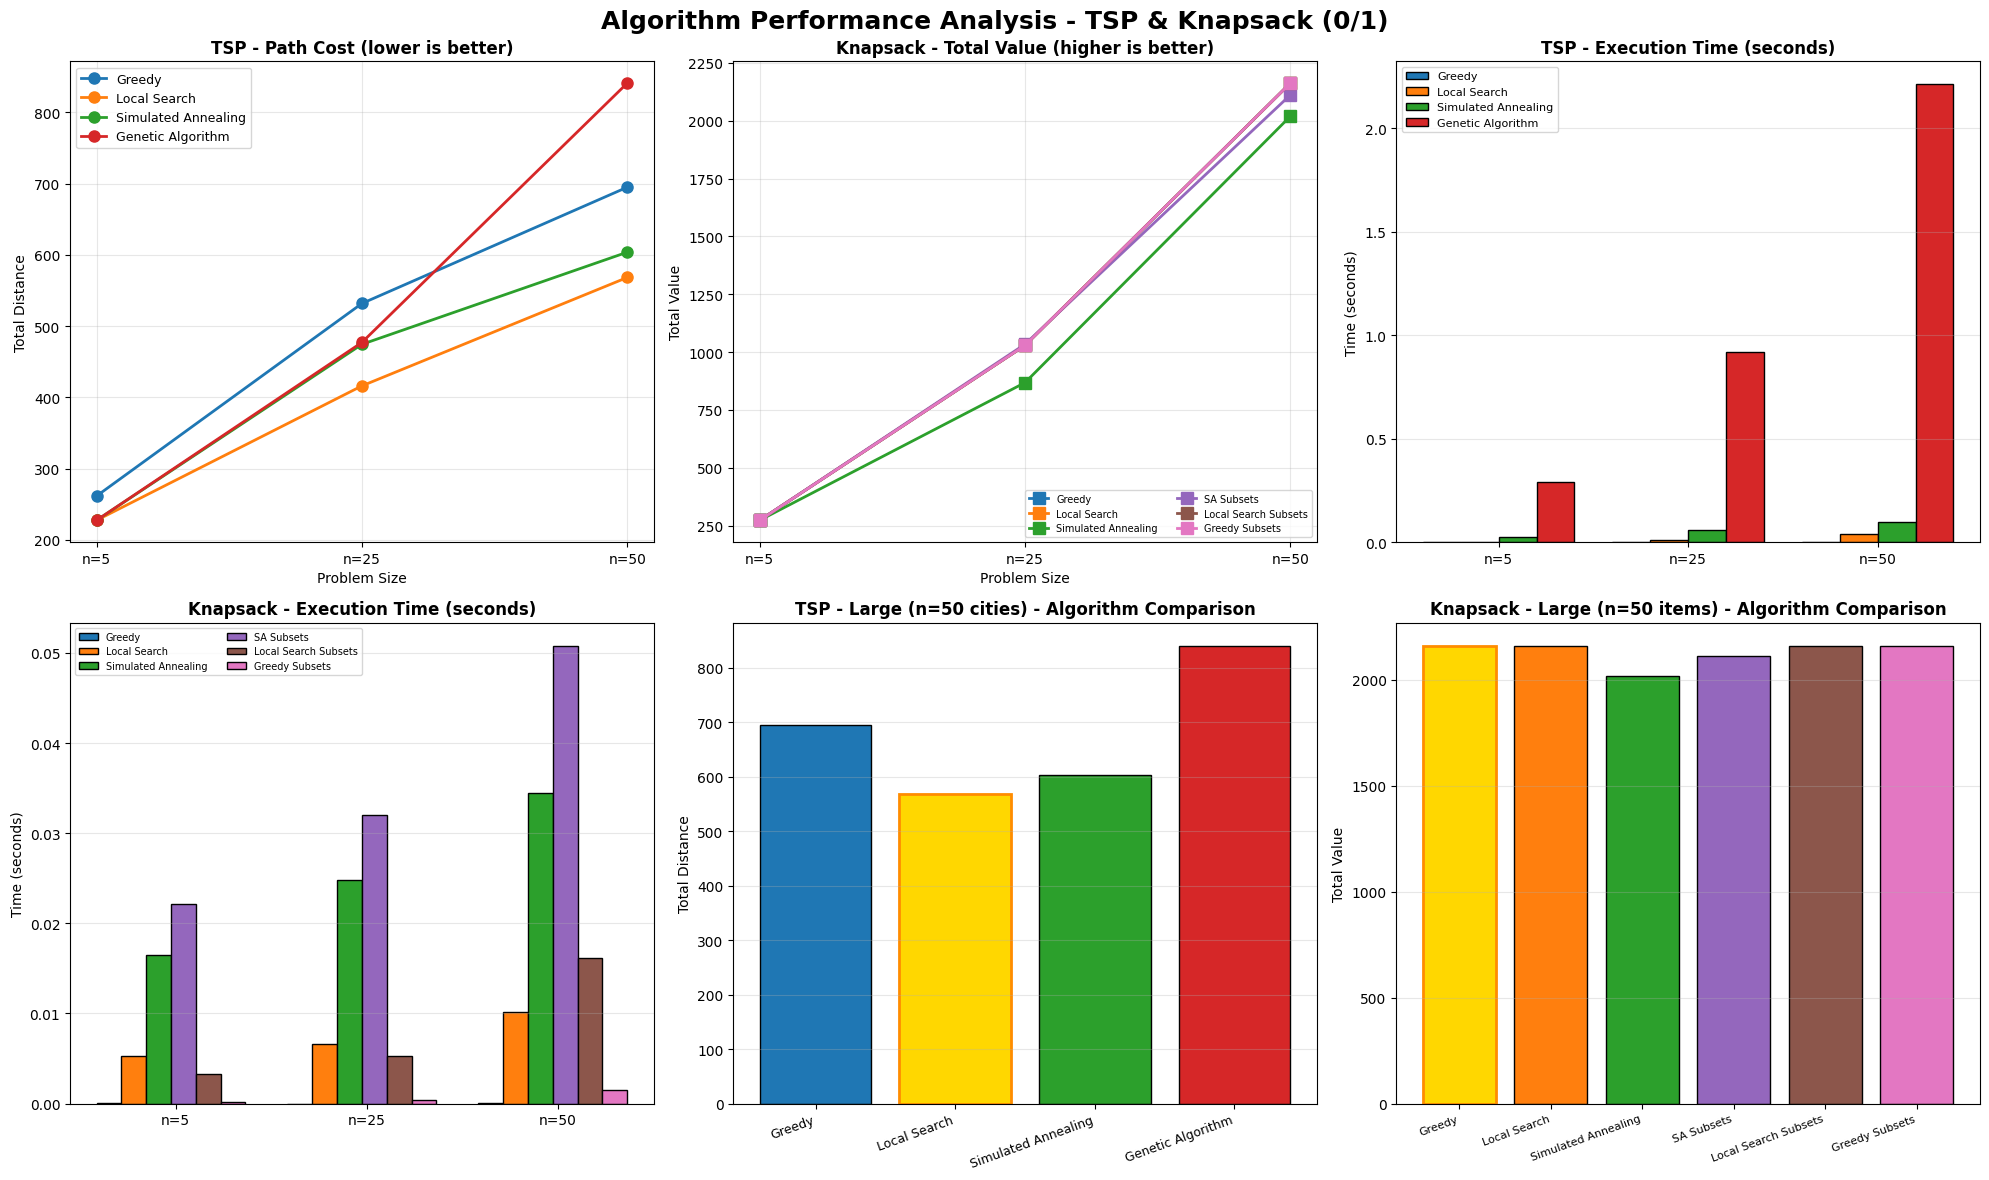

Charts saved to: analysis_charts.png

Execution completed. Results saved to all_algorithm_results.xlsx and analysis_charts.png


In [1]:
# TSP & Knapsack - Greedy, Local Search, Simulated Annealing, Genetic Algorithm

import numpy as np
import random
import math
import time
import pandas as pd
import matplotlib.pyplot as plt
from copy import deepcopy

random.seed(42)
np.random.seed(42)

def generate_tsp_data(n, seed=42):
    np.random.seed(seed)
    cities = np.random.rand(n, 2) * 100
    dist_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                dist_matrix[i][j] = np.linalg.norm(cities[i] - cities[j])
    return cities, dist_matrix

def generate_knapsack_data(n, seed=42):
    np.random.seed(seed)
    weights = np.random.randint(1, 20, n)
    values = np.random.randint(10, 100, n)
    capacity = int(np.sum(weights) * 0.5)
    return weights, values, capacity

SIZES = {'small': 5, 'medium': 25, 'large': 50}
tsp_data = {s: generate_tsp_data(n) for s, n in SIZES.items()}
knapsack_data = {s: generate_knapsack_data(n) for s, n in SIZES.items()}

print('Data generated:')
for s, n in SIZES.items():
    w, v, cap = knapsack_data[s]
    print(f'  [{s:6}] TSP: {n} cities | Knapsack: {n} items, capacity={cap}')

def tsp_route_cost(route, dist_matrix):
    cost = sum(dist_matrix[route[i]][route[i+1]] for i in range(len(route)-1))
    cost += dist_matrix[route[-1]][route[0]]
    return cost

def two_opt_swap(route, i, k):
    return route[:i] + route[i:k+1][::-1] + route[k+1:]

def tsp_greedy(dist_matrix):
    n = len(dist_matrix)
    visited = [False] * n
    route = [0]
    visited[0] = True
    for _ in range(n - 1):
        current = route[-1]
        nearest = min((j for j in range(n) if not visited[j]), key=lambda j: dist_matrix[current][j])
        route.append(nearest)
        visited[nearest] = True
    return route, tsp_route_cost(route, dist_matrix)

def tsp_local_search(dist_matrix, max_iter=1000):
    n = len(dist_matrix)
    route, best_cost = tsp_greedy(dist_matrix)
    improved = True
    iterations = 0
    while improved and iterations < max_iter:
        improved = False
        for i in range(1, n - 1):
            for k in range(i + 1, n):
                new_route = two_opt_swap(route, i, k)
                new_cost = tsp_route_cost(new_route, dist_matrix)
                if new_cost < best_cost:
                    route, best_cost = new_route, new_cost
                    improved = True
        iterations += 1
    return route, best_cost

def tsp_simulated_annealing(dist_matrix, T=1000, alpha=0.995, max_iter=5000):
    n = len(dist_matrix)
    route = list(range(n))
    random.shuffle(route)
    best_route = route[:]
    best_cost = tsp_route_cost(route, dist_matrix)
    current_cost = best_cost
    for _ in range(max_iter):
        i, k = sorted(random.sample(range(n), 2))
        new_route = two_opt_swap(route, i, k)
        new_cost = tsp_route_cost(new_route, dist_matrix)
        delta = new_cost - current_cost
        if delta < 0 or random.random() < math.exp(-delta / T):
            route, current_cost = new_route, new_cost
            if current_cost < best_cost:
                best_route, best_cost = route[:], current_cost
        T *= alpha
    return best_route, best_cost

def tsp_genetic_algorithm(dist_matrix, pop_size=100, generations=500, mutation_rate=0.05):
    n = len(dist_matrix)
    def create_individual():
        ind = list(range(n))
        random.shuffle(ind)
        return ind
    def fitness(ind):
        return 1 / tsp_route_cost(ind, dist_matrix)
    def crossover(p1, p2):
        start, end = sorted(random.sample(range(n), 2))
        child = [None] * n
        child[start:end] = p1[start:end]
        remaining = [x for x in p2 if x not in child]
        idx = 0
        for i in range(n):
            if child[i] is None:
                child[i] = remaining[idx]
                idx += 1
        return child
    def mutate(ind):
        if random.random() < mutation_rate:
            i, j = random.sample(range(n), 2)
            ind[i], ind[j] = ind[j], ind[i]
        return ind
    population = [create_individual() for _ in range(pop_size)]
    best_route, best_cost = None, float('inf')
    for gen in range(generations):
        population.sort(key=fitness, reverse=True)
        curr_cost = tsp_route_cost(population[0], dist_matrix)
        if curr_cost < best_cost:
            best_route, best_cost = population[0][:], curr_cost
        next_gen = population[:20]
        while len(next_gen) < pop_size:
            p1, p2 = random.choices(population[:50], k=2)
            child = mutate(crossover(p1, p2))
            next_gen.append(child)
        population = next_gen
    return best_route, best_cost

print('\nTSP Greedy:')
for size in SIZES:
    _, dm = tsp_data[size]
    t0 = time.time()
    route, cost = tsp_greedy(dm)
    elapsed = time.time() - t0
    print(f'  [{size:6}] cost={cost:.2f} | time={elapsed:.4f}s')

print('\nTSP Local Search:')
for size in SIZES:
    _, dm = tsp_data[size]
    t0 = time.time()
    route, cost = tsp_local_search(dm)
    elapsed = time.time() - t0
    print(f'  [{size:6}] cost={cost:.2f} | time={elapsed:.4f}s')

print('\nTSP Simulated Annealing:')
for size in SIZES:
    _, dm = tsp_data[size]
    t0 = time.time()
    route, cost = tsp_simulated_annealing(dm)
    elapsed = time.time() - t0
    print(f'  [{size:6}] cost={cost:.2f} | time={elapsed:.4f}s')

print('\nTSP Genetic Algorithm:')
for size in SIZES:
    _, dm = tsp_data[size]
    t0 = time.time()
    route, cost = tsp_genetic_algorithm(dm)
    elapsed = time.time() - t0
    print(f'  [{size:6}] cost={cost:.2f} | time={elapsed:.4f}s')

def knapsack_value(solution, weights, values, capacity):
    total_w = np.dot(solution, weights)
    total_v = np.dot(solution, values)
    return total_v if total_w <= capacity else 0

def random_solution(n):
    return [random.randint(0, 1) for _ in range(n)]

def knapsack_greedy(weights, values, capacity):
    n = len(weights)
    ratio = [(values[i]/weights[i], i) for i in range(n)]
    ratio.sort(reverse=True)
    solution = [0] * n
    total_w = 0
    for r, i in ratio:
        if total_w + weights[i] <= capacity:
            solution[i] = 1
            total_w += weights[i]
    return solution, knapsack_value(solution, weights, values, capacity)

print('\nKnapsack Greedy:')
for size in SIZES:
    w, v, cap = knapsack_data[size]
    t0 = time.time()
    sol, val = knapsack_greedy(w, v, cap)
    elapsed = time.time() - t0
    print(f'  [{size:6}] value={val} | items={sum(sol)} | time={elapsed:.4f}s')

def knapsack_local_search(weights, values, capacity, max_iter=1000):
    n = len(weights)
    solution, best_val = knapsack_greedy(weights, values, capacity)
    for _ in range(max_iter):
        i = random.randint(0, n-1)
        neighbor = solution[:]
        neighbor[i] = 1 - neighbor[i]
        val = knapsack_value(neighbor, weights, values, capacity)
        if val > best_val:
            solution, best_val = neighbor, val
    return solution, best_val

print('\nKnapsack Local Search:')
for size in SIZES:
    w, v, cap = knapsack_data[size]
    t0 = time.time()
    sol, val = knapsack_local_search(w, v, cap)
    elapsed = time.time() - t0
    print(f'  [{size:6}] value={val} | items={sum(sol)} | time={elapsed:.4f}s')

def knapsack_simulated_annealing(weights, values, capacity, T=500, alpha=0.99, max_iter=3000):
    n = len(weights)
    solution = random_solution(n)
    best_sol = solution[:]
    best_val = knapsack_value(solution, weights, values, capacity)
    current_val = best_val
    for _ in range(max_iter):
        i = random.randint(0, n-1)
        neighbor = solution[:]
        neighbor[i] = 1 - neighbor[i]
        new_val = knapsack_value(neighbor, weights, values, capacity)
        delta = new_val - current_val
        if delta > 0 or (T > 0.01 and random.random() < math.exp(delta / T)):
            solution, current_val = neighbor, new_val
            if current_val > best_val:
                best_sol, best_val = solution[:], current_val
        T *= alpha
    return best_sol, best_val

print('\nKnapsack Simulated Annealing:')
for size in SIZES:
    w, v, cap = knapsack_data[size]
    t0 = time.time()
    sol, val = knapsack_simulated_annealing(w, v, cap)
    elapsed = time.time() - t0
    print(f'  [{size:6}] value={val} | items={sum(sol)} | time={elapsed:.4f}s')

def knapsack_sa_subsets(weights, values, capacity, T=500, alpha=0.99, max_iter=3000):
    n = len(weights)
    solution = random_solution(n)
    best_sol = solution[:]
    best_val = knapsack_value(solution, weights, values, capacity)
    current_val = best_val
    for _ in range(max_iter):
        k = random.randint(1, max(1, n//4))
        indices = random.sample(range(n), k)
        neighbor = solution[:]
        for idx in indices:
            neighbor[idx] = 1 - neighbor[idx]
        new_val = knapsack_value(neighbor, weights, values, capacity)
        delta = new_val - current_val
        if delta > 0 or (T > 0.01 and random.random() < math.exp(delta / T)):
            solution, current_val = neighbor, new_val
            if current_val > best_val:
                best_sol, best_val = solution[:], current_val
        T *= alpha
    return best_sol, best_val

print('\nKnapsack SA Subsets:')
for size in SIZES:
    w, v, cap = knapsack_data[size]
    t0 = time.time()
    sol, val = knapsack_sa_subsets(w, v, cap)
    elapsed = time.time() - t0
    print(f'  [{size:6}] value={val} | items={sum(sol)} | time={elapsed:.4f}s')

def knapsack_local_search_subsets(weights, values, capacity, max_iter=500):
    n = len(weights)
    solution, best_val = knapsack_greedy(weights, values, capacity)
    for _ in range(max_iter):
        k = random.randint(1, max(1, n//4))
        indices = random.sample(range(n), k)
        neighbor = solution[:]
        for idx in indices:
            neighbor[idx] = 1 - neighbor[idx]
        val = knapsack_value(neighbor, weights, values, capacity)
        if val > best_val:
            solution, best_val = neighbor, val
    return solution, best_val

print('\nKnapsack Local Search Subsets:')
for size in SIZES:
    w, v, cap = knapsack_data[size]
    t0 = time.time()
    sol, val = knapsack_local_search_subsets(w, v, cap)
    elapsed = time.time() - t0
    print(f'  [{size:6}] value={val} | items={sum(sol)} | time={elapsed:.4f}s')

def knapsack_greedy_subsets(weights, values, capacity, n_restarts=20):
    n = len(weights)
    best_sol, best_val = knapsack_greedy(weights, values, capacity)
    for _ in range(n_restarts):
        indices = list(range(n))
        random.shuffle(indices)
        solution = [0] * n
        total_w = 0
        for i in indices:
            if total_w + weights[i] <= capacity:
                solution[i] = 1
                total_w += weights[i]
        val = knapsack_value(solution, weights, values, capacity)
        if val > best_val:
            best_sol, best_val = solution[:], val
    return best_sol, best_val

print('\nKnapsack Greedy Subsets:')
for size in SIZES:
    w, v, cap = knapsack_data[size]
    t0 = time.time()
    sol, val = knapsack_greedy_subsets(w, v, cap)
    elapsed = time.time() - t0
    print(f'  [{size:6}] value={val} | items={sum(sol)} | time={elapsed:.4f}s')

def run_all_algorithms():
    results = []
    tsp_algos = {
        'Greedy': tsp_greedy,
        'Local Search': tsp_local_search,
        'Simulated Annealing': tsp_simulated_annealing,
        'Genetic Algorithm': tsp_genetic_algorithm,
    }
    knapsack_algos = {
        'Greedy': knapsack_greedy,
        'Local Search': knapsack_local_search,
        'Simulated Annealing': knapsack_simulated_annealing,
        'SA Subsets': knapsack_sa_subsets,
        'Local Search Subsets': knapsack_local_search_subsets,
        'Greedy Subsets': knapsack_greedy_subsets,
    }
    print('\nCompiling TSP results:')
    for size in SIZES:
        _, dm = tsp_data[size]
        for name, algo in tsp_algos.items():
            t0 = time.time()
            _, cost = algo(dm)
            elapsed = round(time.time() - t0, 4)
            results.append({'Problem': 'TSP', 'Algorithm': name, 'Size': size, 'N': SIZES[size], 'Result': round(cost, 2), 'Time(s)': elapsed})
            print(f'  {name} [{size}]: {cost:.2f} ({elapsed}s)')
    print('\nCompiling Knapsack results:')
    for size in SIZES:
        w, v, cap = knapsack_data[size]
        for name, algo in knapsack_algos.items():
            t0 = time.time()
            _, val = algo(w, v, cap)
            elapsed = round(time.time() - t0, 4)
            results.append({'Problem': 'Knapsack', 'Algorithm': name, 'Size': size, 'N': SIZES[size], 'Result': val, 'Time(s)': elapsed})
            print(f'  {name} [{size}]: {val} ({elapsed}s)')
    return pd.DataFrame(results)

all_results_df = run_all_algorithms()

def save_to_excel(df, filename='all_algorithm_results.xlsx'):
    with pd.ExcelWriter(filename, engine='openpyxl') as writer:
        df.to_excel(writer, sheet_name='All Results', index=False)
        tsp_df = df[df['Problem'] == 'TSP']
        tsp_pivot = tsp_df.pivot_table(index='Algorithm', columns='Size', values='Result', aggfunc='first')
        tsp_pivot.to_excel(writer, sheet_name='TSP Results')
        ks_df = df[df['Problem'] == 'Knapsack']
        ks_pivot = ks_df.pivot_table(index='Algorithm', columns='Size', values='Result', aggfunc='first')
        ks_pivot.to_excel(writer, sheet_name='Knapsack Results')
        time_pivot = df.pivot_table(index='Algorithm', columns=['Problem','Size'], values='Time(s)', aggfunc='first')
        time_pivot.to_excel(writer, sheet_name='Execution Times')
    print(f'\nSaved to: {filename}')

save_to_excel(all_results_df)

def generate_charts(df):
    fig = plt.figure(figsize=(20, 12))
    fig.suptitle('Algorithm Performance Analysis - TSP & Knapsack (0/1)', fontsize=18, fontweight='bold')

    tsp_colors = {'Greedy': '#1f77b4', 'Local Search': '#ff7f0e', 'Simulated Annealing': '#2ca02c', 'Genetic Algorithm': '#d62728'}
    ks_colors = {'Greedy': '#1f77b4', 'Local Search': '#ff7f0e', 'Simulated Annealing': '#2ca02c', 'SA Subsets': '#9467bd', 'Local Search Subsets': '#8c564b', 'Greedy Subsets': '#e377c2'}

    sizes_order = ['small', 'medium', 'large']
    size_labels = {'small': 'n=5', 'medium': 'n=25', 'large': 'n=50'}

    ax1 = plt.subplot(2, 3, 1)
    tsp_df = df[df['Problem'] == 'TSP']
    for algo, color in tsp_colors.items():
        sub = tsp_df[tsp_df['Algorithm'] == algo].set_index('Size').reindex(sizes_order)
        ax1.plot([size_labels[s] for s in sizes_order], sub['Result'], marker='o', linewidth=2, markersize=8, label=algo, color=color)
    ax1.set_title('TSP - Path Cost (lower is better)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Problem Size')
    ax1.set_ylabel('Total Distance')
    ax1.legend(loc='upper left', fontsize=9)
    ax1.grid(True, alpha=0.3)

    ax2 = plt.subplot(2, 3, 2)
    ks_df = df[df['Problem'] == 'Knapsack']
    for algo, color in ks_colors.items():
        sub = ks_df[ks_df['Algorithm'] == algo].set_index('Size').reindex(sizes_order)
        ax2.plot([size_labels[s] for s in sizes_order], sub['Result'], marker='s', linewidth=2, markersize=8, label=algo, color=color)
    ax2.set_title('Knapsack - Total Value (higher is better)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Problem Size')
    ax2.set_ylabel('Total Value')
    ax2.legend(loc='lower right', fontsize=7, ncol=2)
    ax2.grid(True, alpha=0.3)

    ax3 = plt.subplot(2, 3, 3)
    for algo, color in tsp_colors.items():
        sub = tsp_df[tsp_df['Algorithm'] == algo].set_index('Size').reindex(sizes_order)
        ax3.bar(np.arange(3) + list(tsp_colors.keys()).index(algo)*0.2, sub['Time(s)'], width=0.2, label=algo, color=color, edgecolor='black')
    ax3.set_title('TSP - Execution Time (seconds)', fontsize=12, fontweight='bold')
    ax3.set_xticks(np.arange(3) + 0.3)
    ax3.set_xticklabels([size_labels[s] for s in sizes_order])
    ax3.set_ylabel('Time (seconds)')
    ax3.legend(loc='upper left', fontsize=8)
    ax3.grid(True, alpha=0.3, axis='y')

    ax4 = plt.subplot(2, 3, 4)
    for algo, color in ks_colors.items():
        sub = ks_df[ks_df['Algorithm'] == algo].set_index('Size').reindex(sizes_order)
        ax4.bar(np.arange(3) + list(ks_colors.keys()).index(algo)*0.13, sub['Time(s)'], width=0.13, label=algo, color=color, edgecolor='black')
    ax4.set_title('Knapsack - Execution Time (seconds)', fontsize=12, fontweight='bold')
    ax4.set_xticks(np.arange(3) + 0.35)
    ax4.set_xticklabels([size_labels[s] for s in sizes_order])
    ax4.set_ylabel('Time (seconds)')
    ax4.legend(loc='upper left', fontsize=7, ncol=2)
    ax4.grid(True, alpha=0.3, axis='y')

    ax5 = plt.subplot(2, 3, 5)
    tsp_large = tsp_df[tsp_df['Size'] == 'large']
    bars = ax5.bar(range(len(tsp_large)), tsp_large['Result'], color=[tsp_colors[a] for a in tsp_large['Algorithm']], edgecolor='black')
    ax5.set_xticks(range(len(tsp_large)))
    ax5.set_xticklabels(tsp_large['Algorithm'], rotation=20, ha='right', fontsize=9)
    ax5.set_title('TSP - Large (n=50 cities) - Algorithm Comparison', fontsize=12, fontweight='bold')
    ax5.set_ylabel('Total Distance')
    ax5.grid(True, alpha=0.3, axis='y')
    best_idx = tsp_large['Result'].idxmin()
    bars[tsp_large.index.get_loc(best_idx)].set_color('gold')
    bars[tsp_large.index.get_loc(best_idx)].set_edgecolor('darkorange')
    bars[tsp_large.index.get_loc(best_idx)].set_linewidth(2)

    ax6 = plt.subplot(2, 3, 6)
    ks_large = ks_df[ks_df['Size'] == 'large']
    bars = ax6.bar(range(len(ks_large)), ks_large['Result'], color=[ks_colors[a] for a in ks_large['Algorithm']], edgecolor='black')
    ax6.set_xticks(range(len(ks_large)))
    ax6.set_xticklabels(ks_large['Algorithm'], rotation=20, ha='right', fontsize=8)
    ax6.set_title('Knapsack - Large (n=50 items) - Algorithm Comparison', fontsize=12, fontweight='bold')
    ax6.set_ylabel('Total Value')
    ax6.grid(True, alpha=0.3, axis='y')
    best_idx = ks_large['Result'].idxmax()
    bars[ks_large.index.get_loc(best_idx)].set_color('gold')
    bars[ks_large.index.get_loc(best_idx)].set_edgecolor('darkorange')
    bars[ks_large.index.get_loc(best_idx)].set_linewidth(2)

    plt.tight_layout()
    plt.savefig('analysis_charts.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Charts saved to: analysis_charts.png')

generate_charts(all_results_df)

print('\nExecution completed. Results saved to all_algorithm_results.xlsx and analysis_charts.png')